In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

In [2]:
# Load the iris dataset
iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

print(iris.feature_names)
print(iris.target_names)

(150, 4)
(150,)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [4]:
# Train test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [6]:
# Create the XGBoost classifier
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

In [7]:
# Train the model
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [8]:
# Make predictions
y_pred = model.predict(X_test)

In [10]:
# Compare actual vs predicted
for actual, predicted in zip(y_test, y_pred):
    print(
        f"Actual: {iris.target_names[actual]:10s} "
        f"Predicted: {iris.target_names[predicted]}"
    )

Actual: setosa     Predicted: setosa
Actual: virginica  Predicted: virginica
Actual: versicolor Predicted: versicolor
Actual: versicolor Predicted: versicolor
Actual: setosa     Predicted: setosa
Actual: versicolor Predicted: versicolor
Actual: setosa     Predicted: setosa
Actual: setosa     Predicted: setosa
Actual: virginica  Predicted: virginica
Actual: versicolor Predicted: versicolor
Actual: virginica  Predicted: virginica
Actual: virginica  Predicted: virginica
Actual: virginica  Predicted: virginica
Actual: versicolor Predicted: versicolor
Actual: setosa     Predicted: setosa
Actual: setosa     Predicted: setosa
Actual: setosa     Predicted: setosa
Actual: versicolor Predicted: versicolor
Actual: versicolor Predicted: versicolor
Actual: virginica  Predicted: versicolor
Actual: setosa     Predicted: setosa
Actual: virginica  Predicted: virginica
Actual: versicolor Predicted: versicolor
Actual: virginica  Predicted: virginica
Actual: virginica  Predicted: virginica
Actual: versico

In [11]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [12]:
# Classification report
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


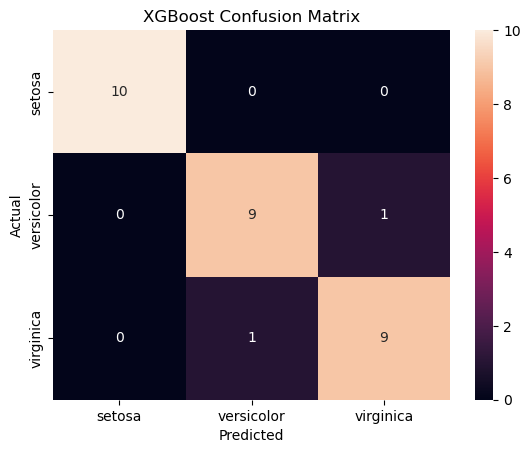

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [21]:
new_flower = [[5.8, 3.0, 4.2, 1.2]]
prediction = model.predict(new_flower)

print(prediction)
print(iris.target_names[prediction[0]])

[1]
versicolor


In [22]:
probabilities = model.predict_proba(new_flower)

print(probabilities)

[[0.00467743 0.9927279  0.00259477]]
